Importing the dataset


In [ ]:
import pandas as pd

In [ ]:
file_path = '/content/Data_set.xlsx'

In [ ]:
amp_df = pd.read_excel(file_path, sheet_name='AMP')
non_amp_df = pd.read_excel(file_path, sheet_name='non-AMP')


Label Encoding

In [ ]:
amp_df["Label"] = 1
non_amp_df["Label"] = 0

In [ ]:
df = pd.concat([amp_df, non_amp_df], axis=0, ignore_index=True)

In [ ]:
print("Combined Shape:", df.shape)

Combined Shape: (6338, 7)


In [ ]:
df.to_csv("AMP_Combined_Dataset.csv", index=False)

Exploratory Data Analysis

In [ ]:
df.head()

,Peptide_ID,Title,Sequence,Source_Organism,Activity,Gram_Nature,Label
0,CAMPSQ7,Sesquin,KTCENLADTY,Vigna unguiculata subsp. sesquipedalis,AMP,"Gram+ve, Gram-ve",1
1,CAMPSQ17,Antifungal lectin PVAP,SNDIYFNFQR,Phaseolus vulgaris,AMP,NaN,1
2,CAMPSQ519,Gymnin,KTCENLADDY,Gymnocladus chinensis,AMP,NaN,1
3,CAMPSQ593,Antimicrobial ribonuclease,DNGEAGRAAR,Lentinus sajor-caju,AMP,"Gram+ve, Gram-ve",1
4,CAMPSQ652,Coccinin,KQTENLADTY,Phaseolus coccineus,AMP,NaN,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6338 entries, 0 to 6337
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Peptide_ID       6338 non-null   object
 1   Title            6338 non-null   object
 2   Sequence         6338 non-null   object
 3   Source_Organism  6338 non-null   object
 4   Activity         6338 non-null   object
 5   Gram_Nature      1903 non-null   object
 6   Label            6338 non-null   int64 
dtypes: int64(1), object(6)
memory usage: 346.7+ KB


In [ ]:
df.describe()

,Label
count,6338.00000
mean,0.41622
std,0.49297
min,0.00000
25%,0.00000
50%,0.00000
75%,1.00000
max,1.00000


In [ ]:
df['Activity'].value_counts()

,count
Activity,
non-AMP,3700
AMP,2638


Feature Extraction

creating feature length feature

In [ ]:
df["length"] = df["Sequence"].apply(len)

In [ ]:
df["length"].describe()

,length
count,6338.000000
mean,47.992742
std,24.271203
min,10.000000
25%,26.000000
50%,45.000000
75%,70.000000
max,90.000000


Class Distribution plot

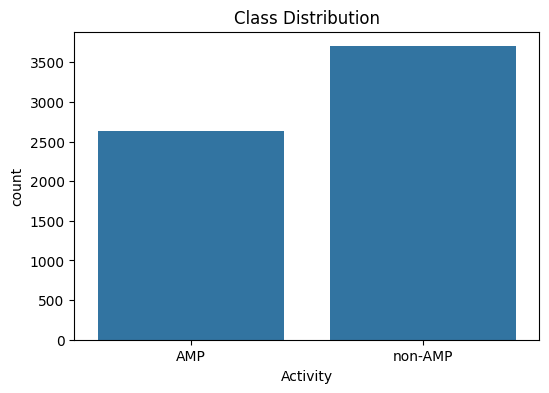

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.countplot(
    x='Activity',
    data=df
)
plt.title('Class Distribution')
plt.show()

Length Distribution

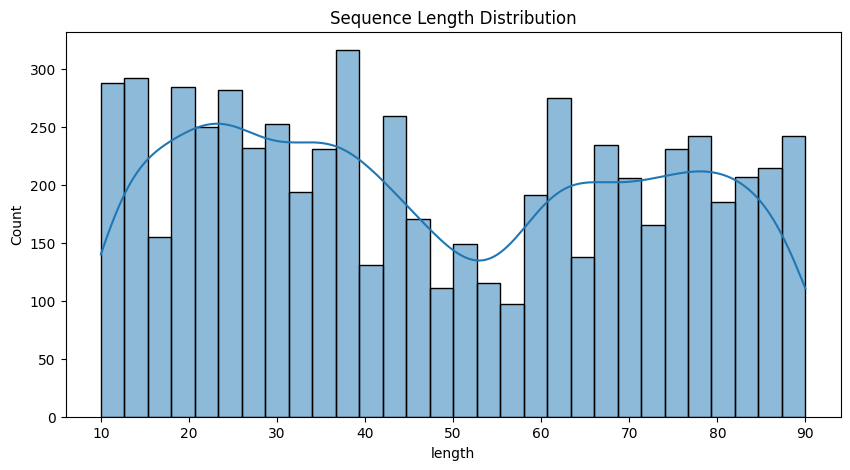

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(
    df['length'],
    bins = 30,
    kde = True
)
plt.title('Sequence Length Distribution')
plt.show()

AMP VS NON AMP Length

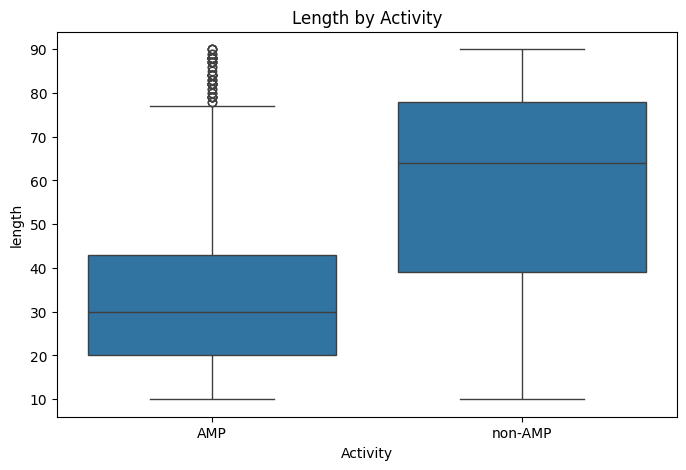

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x = 'Activity',
    y = 'length',
    data = df
)
plt.title('Length by Activity')
plt.show()

Showing that amp length is usually smaller compared to non-amp and there is some intersection region with similar length in both amp's and non amp's

counting no.of Amino acids across the dataset

In [ ]:
from collections import Counter

all_sequences = ''.join(df['Sequence'])

aa_counts = Counter(all_sequences)

aa_counts

Counter({'K': 22528,
         'T': 14127,
         'C': 16380,
         'E': 14765,
         'N': 11600,
         'L': 27182,
         'A': 22830,
         'D': 13032,
         'Y': 8717,
         'S': 19321,
         'I': 16945,
         'F': 12636,
         'Q': 10020,
         'R': 17730,
         'G': 25418,
         'M': 8101,
         'W': 4180,
         'V': 18923,
         'P': 13436,
         'H': 6307})

In [ ]:
import pandas as pd

aa_df = pd.DataFrame(
    aa_counts.items(),
    columns=['AA', 'Count']
)

aa_df = aa_df.sort_values(
    by='Count',
    ascending=False
)

print(aa_df)

   AA  Count
5   L  27182
14  G  25418
6   A  22830
0   K  22528
9   S  19321
17  V  18923
13  R  17730
10  I  16945
2   C  16380
3   E  14765
1   T  14127
18  P  13436
7   D  13032
11  F  12636
4   N  11600
12  Q  10020
8   Y   8717
15  M   8101
19  H   6307
16  W   4180


counting no.of amino acids in AMP and NON - AMP seperatly

In [ ]:
from collections import Counter

def count_amino_acids(sequences):
    all_seq = ''.join(sequences)
    return Counter(all_seq)

In [ ]:
amp_counts = count_amino_acids(
    amp_df["Sequence"]
)

non_amp_counts = count_amino_acids(
    non_amp_df["Sequence"]
)

EDA of AAC in amp's and non-amp's

In [ ]:
aa = list("ACDEFGHIKLMNPQRSTVWY")

comparison = pd.DataFrame({
    "AA": aa,
    "AMP": [amp_counts.get(x,0) for x in aa],
    "non_AMP": [non_amp_counts.get(x,0) for x in aa]
})

comparison

,AA,AMP,non_AMP
0,A,6533,16297
1,C,6509,9871
2,D,2410,10622
3,E,2737,12028
4,F,3389,9247
5,G,9670,15748
6,H,1969,4338
7,I,5153,11792
8,K,8847,13681
9,L,7256,19926


In [ ]:
amp_total = comparison["AMP"].sum()

comparison["AMP_freq"] = (
    comparison["AMP"] / amp_total
)

In [ ]:
non_total = comparison["non_AMP"].sum()

comparison["nonAMP_freq"] = (
    comparison["non_AMP"] / non_total
)

In [ ]:
comparison["Difference"] = (
    comparison["AMP_freq"]
    - comparison["nonAMP_freq"]
)

In [ ]:
comparison.sort_values(
    "Difference",
    ascending=False
)

,AA,AMP,non_AMP,AMP_freq,nonAMP_freq,Difference
8,K,8847,13681,0.099843,0.063465,0.036379
5,G,9670,15748,0.109131,0.073053,0.036078
1,C,6509,9871,0.073458,0.045790,0.027667
14,R,5443,12287,0.061427,0.056998,0.004429
7,I,5153,11792,0.058154,0.054702,0.003453
18,W,1406,2774,0.015867,0.012868,0.002999
6,H,1969,4338,0.022221,0.020123,0.002098
12,P,3988,9448,0.045007,0.043828,0.001179
11,N,3424,8176,0.038642,0.037928,0.000714
0,A,6533,16297,0.073728,0.075600,-0.001872


In [ ]:
df.head()

,Peptide_ID,Title,Sequence,Source_Organism,Activity,Gram_Nature,Label,length
0,CAMPSQ7,Sesquin,KTCENLADTY,Vigna unguiculata subsp. sesquipedalis,AMP,"Gram+ve, Gram-ve",1,10
1,CAMPSQ17,Antifungal lectin PVAP,SNDIYFNFQR,Phaseolus vulgaris,AMP,NaN,1,10
2,CAMPSQ519,Gymnin,KTCENLADDY,Gymnocladus chinensis,AMP,NaN,1,10
3,CAMPSQ593,Antimicrobial ribonuclease,DNGEAGRAAR,Lentinus sajor-caju,AMP,"Gram+ve, Gram-ve",1,10
4,CAMPSQ652,Coccinin,KQTENLADTY,Phaseolus coccineus,AMP,NaN,1,10


Model Training-Logistic regression with only length of the sequence as the basis

In [ ]:
x = df[['length']]
y = df['Label']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train_scaled,y_train)

LogisticRegression()

In [ ]:
y_pred = lr.predict(x_test_scaled)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.7294952681388013


This shows that length alone is not enough critaria for classification

visualization

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[574 166]
 [177 351]]


177 amp's are still missing we have to minimise them

Prediction Metrices

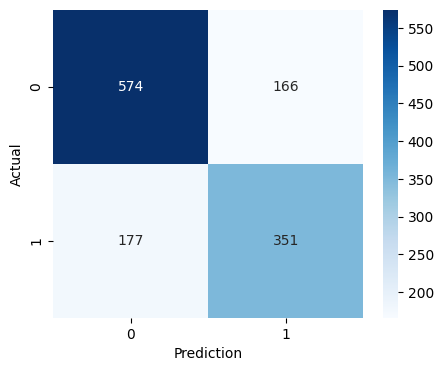

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot = True,
    fmt='d',
    cmap = 'Blues'
)
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.metrics import (precision_score,f1_score,recall_score)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
print('precision : ',precision)
print('recall : ',recall)
print('f1_score : ',f1)

precision :  0.6789168278529981
recall :  0.6647727272727273
f1_score :  0.6717703349282297


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.78      0.77       740
           1       0.68      0.66      0.67       528

    accuracy                           0.73      1268
   macro avg       0.72      0.72      0.72      1268
weighted avg       0.73      0.73      0.73      1268



AAC Feature extraction

Defining function for aac

In [ ]:
def aac(sequence):

    amino_acids = "ACDEFGHIKLMNPQRSTVWY"

    features = {}

    for aa in amino_acids:
        features[aa] = sequence.count(aa)/len(sequence)

    return features

In [ ]:
aac_df = df["Sequence"].apply(aac)

In [ ]:
aac_df = pd.DataFrame(
    aac_df.tolist()
)

In [ ]:
aac_df.head()

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
0,0.1,0.1,0.1,0.1,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.1,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.1
1,0.0,0.0,0.1,0.0,0.2,0.0,0.0,0.1,0.0,0.0,0.0,0.2,0.0,0.1,0.1,0.1,0.0,0.0,0.0,0.1
2,0.1,0.1,0.2,0.1,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.1
3,0.3,0.0,0.1,0.1,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0
4,0.1,0.0,0.1,0.1,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.1,0.0,0.1,0.0,0.0,0.2,0.0,0.0,0.1


In [ ]:
aac_df.shape

(6338, 20)

adding length column from the previous dataframe to the new one

In [ ]:
aac_df["length"] = df["length"]

In [ ]:
aac_df.shape

(6338, 21)

Now training the logistic regression with new features extracted (AAC + Length) with total of 21 features

In [ ]:
x = aac_df
y = df['Label']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42,stratify = y)
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    max_iter = 1000
)
lr.fit(x_train_scaled,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = lr.predict(x_test_scaled)

In [ ]:
print('Accuracy : ',accuracy_score(y_test,y_pred))
print('precision : ',precision_score(y_test,y_pred))
print('recall : ',recall_score(y_test,y_pred))
print('f1_score : ',f1_score(y_test,y_pred))
cm = confusion_matrix(y_test,y_pred)
print('confusion matrix : \n',cm)

Accuracy :  0.8186119873817035
precision :  0.7933070866141733
recall :  0.7632575757575758
f1_score :  0.777992277992278
confusion matrix : 
 [[635 105]
 [125 403]]


missing amp's droped to 125 fine it's working bit

Prediction metrices

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       740
           1       0.79      0.76      0.78       528

    accuracy                           0.82      1268
   macro avg       0.81      0.81      0.81      1268
weighted avg       0.82      0.82      0.82      1268



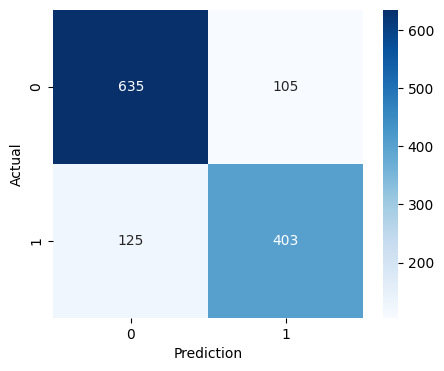

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot = True,
    fmt='d',
    cmap = 'Blues'
)
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

Explainability of the of logistic model - matching with the known biological facts

positively influencing features of the amp prediction

In [ ]:
coef_df = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": lr.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient
8,K,0.827373
1,C,0.300508
14,R,0.215945
6,H,0.110898
7,I,0.098786
11,N,0.062808
5,G,0.057676
13,Q,0.030018
0,A,0.025510
18,W,0.013514


Negatively influencing the prediction of amp's - inversely proportional

In [ ]:
coef_df.tail(10)

,Feature,Coefficient
19,Y,-0.058292
17,V,-0.097278
16,T,-0.105793
12,P,-0.203987
15,S,-0.236476
4,F,-0.238850
3,E,-0.390652
2,D,-0.566358
10,M,-0.783341
20,length,-1.028310


Training with Decision Tree Model (21 features)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state = 42)
dt.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = dt.predict(x_test)
print('Accuracy : ',accuracy_score(y_test,y_pred))
print('precision : ',precision_score(y_test,y_pred))
print('recall : ',recall_score(y_test,y_pred))
print('F1 score : ',f1_score(y_test,y_pred))
cm = confusion_matrix(y_test,y_pred)
print('confusion matrix : \n',cm)

Accuracy :  0.8517350157728707
precision :  0.8113553113553114
recall :  0.8390151515151515
F1 score :  0.8249534450651769
confusion matrix : 
 [[637 103]
 [ 85 443]]


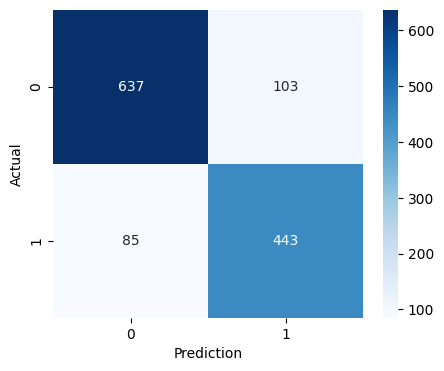

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot = True,
    fmt='d',
    cmap = 'Blues'
)
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       740
           1       0.81      0.84      0.82       528

    accuracy                           0.85      1268
   macro avg       0.85      0.85      0.85      1268
weighted avg       0.85      0.85      0.85      1268



checking for overfitting

In [ ]:
y_train_pred = dt.predict(x_train)
print('Train data accuracy : ',accuracy_score(y_train,y_train_pred))

Train data accuracy :  1.0


model is overfitted

Random Forest ( 21 features )

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)
rf.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_trian_pred = rf.predict(x_train)
y_test_pred = rf.predict(x_test)
print('Accuracy of trained data : ',accuracy_score(y_train,y_train_pred))
print('Accuracy of the test data : ',accuracy_score(y_test,y_test_pred))
print('precision : ',precision_score(y_test,y_test_pred))
print('Recall : ',recall_score(y_test,y_test_pred))
print('F1 score : ',f1_score(y_test,y_test_pred))
cm = confusion_matrix(y_test,y_test_pred)
print('confusion matrix : \n',confusion_matrix(y_test,y_test_pred))

Accuracy of trained data :  1.0
Accuracy of the test data :  0.9069400630914827
precision :  0.9019607843137255
Recall :  0.8712121212121212
F1 score :  0.8863198458574181
confusion matrix : 
 [[690  50]
 [ 68 460]]


significant drop in missing amp's

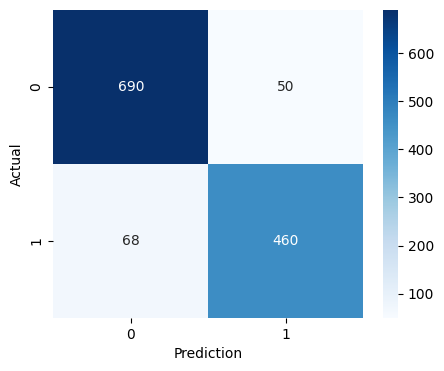

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot = True,
    fmt='d',
    cmap = 'Blues'
)
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

Explainability

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

   Feature  Importance
10       M    0.139676
20  length    0.136840
8        K    0.085718
2        D    0.076540
1        C    0.051835
14       R    0.050872
3        E    0.048242
9        L    0.044433
5        G    0.044363
12       P    0.043029
15       S    0.034340
0        A    0.032222
19       Y    0.030729
7        I    0.029097
4        F    0.026177


cross validion to check irregularities in data and data quality

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    x,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

[0.41876972 0.37933754 0.66719243 0.73007103 0.60299921]
Mean: 0.5596739858430082
Std: 0.13772994726952495


data is fine minimal deviation within data

In [ ]:
x.head()

,A,C,D,E,F,G,H,I,K,L,...,N,P,Q,R,S,T,V,W,Y,length
0,0.1,0.1,0.1,0.1,0.0,0.0,0.0,0.0,0.1,0.1,...,0.1,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.1,10
1,0.0,0.0,0.1,0.0,0.2,0.0,0.0,0.1,0.0,0.0,...,0.2,0.0,0.1,0.1,0.1,0.0,0.0,0.0,0.1,10
2,0.1,0.1,0.2,0.1,0.0,0.0,0.0,0.0,0.1,0.1,...,0.1,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.1,10
3,0.3,0.0,0.1,0.1,0.0,0.2,0.0,0.0,0.0,0.0,...,0.1,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,10
4,0.1,0.0,0.1,0.1,0.0,0.0,0.0,0.0,0.1,0.1,...,0.1,0.0,0.1,0.0,0.0,0.2,0.0,0.0,0.1,10


In [ ]:
print(x.shape)

print(x.columns)

print(y.value_counts())

(6338, 21)
Index(['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q',
       'R', 'S', 'T', 'V', 'W', 'Y', 'length'],
      dtype='object')
Label
0    3700
1    2638
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_cv = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf_cv,
    x,
    y,
    cv=skf,
    scoring='accuracy'
)

print("Fold Scores:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

Fold Scores: [0.90772871 0.90536278 0.91088328 0.90134175 0.90765588]
Mean: 0.9065944791217984
Std: 0.0031595916296100132


perfect no isues scores are almost same

Support vector machine

SVM - KERNEL = RBF

In [ ]:
from sklearn.svm import SVC
svm = SVC(
    kernel='rbf',
    random_state = 42
)
import time
start_train = time.perf_counter()
svm.fit(
    x_train_scaled,
    y_train
)
end_train = time.perf_counter()
training_time = end_train - start_train
print('training time : ',training_time)

training time :  0.6070981010000196


In [ ]:
y_train_pred = svm.predict(x_train_scaled)
start_train = time.perf_counter()
y_test_pred = svm.predict(x_test_scaled)
end_train = time.perf_counter()
prediction_time = end_train - start_train
print('Accuracy of the test data : ',accuracy_score(y_test,y_test_pred))
print('Accuracy of the train data : ',accuracy_score(y_train,y_train_pred))
print('precision : ',precision_score(y_test,y_test_pred))
print('recall : ',recall_score(y_test,y_test_pred))
print('f1 score : ',f1_score(y_test,y_test_pred))
print('training time : ',training_time)
print('prediction time : ',prediction_time)
cm = confusion_matrix(y_test,y_test_pred)
print('confusion matrix : \n',cm)
print(classification_report(y_test,y_test_pred))

Accuracy of the test data :  0.9022082018927445
Accuracy of the train data :  0.9291913214990138
precision :  0.8976377952755905
recall :  0.8636363636363636
f1 score :  0.8803088803088803
training time :  0.6070981010000196
prediction time :  0.1465385440000091
confusion matrix : 
 [[688  52]
 [ 72 456]]
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       740
           1       0.90      0.86      0.88       528

    accuracy                           0.90      1268
   macro avg       0.90      0.90      0.90      1268
weighted avg       0.90      0.90      0.90      1268



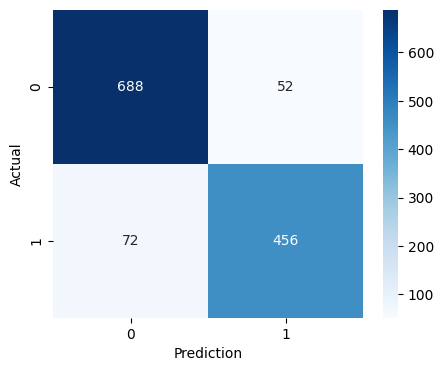

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot = True,
    fmt='d',
    cmap = 'Blues'
)
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state = 42)
gb.fit(x_train,y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
y_train_pred = gb.predict(x_train)
y_test_pred = gb.predict(x_test)
print('Accuracy of test data : ',accuracy_score(y_test,y_test_pred))
print('Accuracy of train data : ',accuracy_score(y_train,y_train_pred))
print('precision : ',precision_score(y_test,y_test_pred))
print('recall : ',recall_score(y_test,y_test_pred))
print('f1 score : ',f1_score(y_test,y_test_pred))
cm = confusion_matrix(y_test,y_test_pred)
print('confusion matrix : \n',confusion_matrix(y_test,y_test_pred))
print(classification_report(y_test,y_test_pred))

Accuracy of test data :  0.8698738170347003
Accuracy of train data :  0.9094674556213018
precision :  0.8565815324165029
recall :  0.8257575757575758
f1 score :  0.840887174541948
confusion matrix : 
 [[667  73]
 [ 92 436]]
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       740
           1       0.86      0.83      0.84       528

    accuracy                           0.87      1268
   macro avg       0.87      0.86      0.87      1268
weighted avg       0.87      0.87      0.87      1268



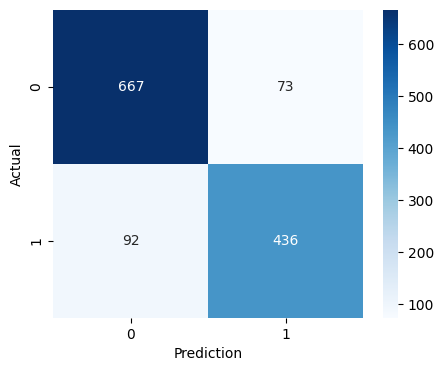

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot = True,
    fmt='d',
    cmap = 'Blues'
)
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

XGB classifier

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    random_state = 42,
    eval_metric = 'logloss'
)
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_train_pred = xgb.predict(x_train)
y_test_pred = xgb.predict(x_test)
print('Accuracy of the training data : ',accuracy_score(y_train,y_train_pred))
print('Accuracy of the test data : ',accuracy_score(y_test,y_test_pred))
print('recall : ',recall_score(y_test,y_test_pred))
print('f1 score : ',f1_score(y_test,y_test_pred))
print('precision : ',precision_score(y_test,y_test_pred))
print(classification_report(y_test,y_test_pred))
cm = confusion_matrix(y_test,y_test_pred)
print('confusion matrix : \n',confusion_matrix(y_test,y_test_pred))


Accuracy of the training data :  1.0
Accuracy of the test data :  0.9069400630914827
recall :  0.8825757575757576
f1 score :  0.8876190476190476
precision :  0.89272030651341
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       740
           1       0.89      0.88      0.89       528

    accuracy                           0.91      1268
   macro avg       0.90      0.90      0.90      1268
weighted avg       0.91      0.91      0.91      1268

confusion matrix : 
 [[684  56]
 [ 62 466]]


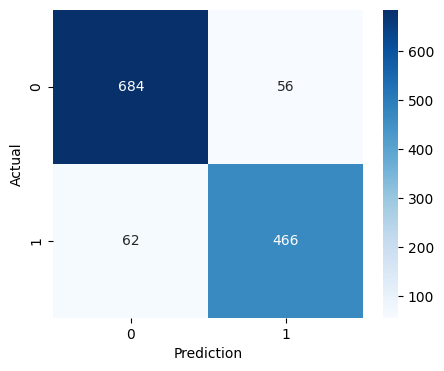

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot = True,
    fmt='d',
    cmap = 'Blues'
)
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

Evaluation

In [ ]:
rf_probs = rf.predict_proba(x_test)[:,1]

In [ ]:
xgb_probs = xgb.predict_proba(x_test)[:,1]

In [ ]:
lr_probs = lr.predict_proba(x_test_scaled)[:,1]

In [ ]:
SVC(
    probability=True
)

SVC(probability=True)

In [ ]:
gb_probs = gb.predict_proba(x_test)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(
    y_test,
    rf_probs
)
print('Roc-auc of rf : ',roc_auc)

Roc-auc of rf :  0.9643389127764127


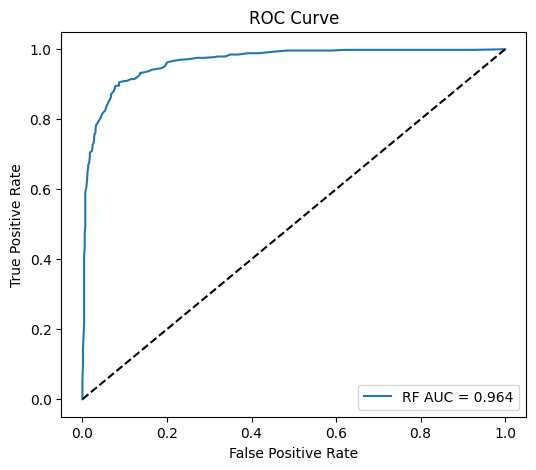

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr,
         label=f'RF AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import average_precision_score
avg_prec = average_precision_score(
    y_test,
    rf_probs
)
print('Average precision of rf : ',avg_prec)

Average precision of rf :  0.9489215947672144


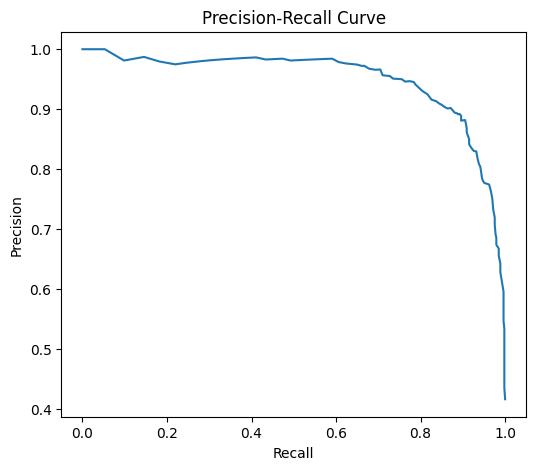

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_test,
    rf_probs
)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(
    y_test,
    xgb_probs
)
print('roc_auc of xgb : ',roc_auc)

roc_auc of xgb :  0.9650312244062245


In [ ]:
from sklearn.metrics import average_precision_score
avg_prec = average_precision_score(
    y_test,
    xgb_probs
)
print('Average precision of xgb : ',avg_prec)

Average precision of xgb :  0.939722611690405


In [ ]:
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [10, 20, None],
#     'min_samples_split': [2, 5]
# }
# from sklearn.model_selection import GridSearchCV
# grid = GridSearchCV(
#     rf,
#     param_grid,
#     cv=5,
#     scoring='f1',
#     n_jobs=-1
# )
# grid.fit(x_train,y_train)

In [ ]:
# best_params = grid.best_params_
# best_cv = grid.best_score_
# test_accuracy = grid.score(x_test,y_test)
# y_pred = grid.predict(x_test)
# test_f1 = f1_score(y_test,y_pred)


In [ ]:
# print('Best parameters are : ',best_params)
# print('Best cv score : ',best_cv)
# print('Score : ',test_accuracy)
# print('f1 score : ',test_f1)


In [ ]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY"

dipeptides = []

for aa1 in amino_acids:
    for aa2 in amino_acids:
        dipeptides.append(aa1 + aa2)

print(len(dipeptides))

400


In [ ]:
def dpc(sequence):

    amino_acids = "ACDEFGHIKLMNPQRSTVWY"

    # Create all 400 dipeptides
    dipeptides = [
        aa1 + aa2
        for aa1 in amino_acids
        for aa2 in amino_acids
    ]

    # Initialize all counts to zero
    features = {dp: 0 for dp in dipeptides}

    # Count observed dipeptides
    for i in range(len(sequence) - 1):

        dp = sequence[i:i+2]

        if dp in features:
            features[dp] += 1

    # Convert counts to frequencies
    total_dp = len(sequence) - 1

    if total_dp > 0:
        for dp in features:
            features[dp] = features[dp] / total_dp

    return features

In [ ]:
dpc_df = df["Sequence"].apply(dpc)

In [ ]:
dpc_df = pd.DataFrame(
    dpc_df.tolist()
)

In [ ]:
print(dpc_df.shape)

(6338, 400)


In [ ]:
x_new = pd.concat(
    [
        aac_df.drop(columns=["length"]),
        dpc_df,
        df["length"]
    ],
    axis=1
)

In [ ]:
print(x_new.shape)

(6338, 421)


In [ ]:
print(dpc_df.shape)
print(x_new.shape)
print(dpc_df.head())

(6338, 400)
(6338, 421)
         AA   AC        AD   AE   AF        AG   AH   AI   AK   AL  ...   YM  \
0  0.000000  0.0  0.111111  0.0  0.0  0.000000  0.0  0.0  0.0  0.0  ...  0.0   
1  0.000000  0.0  0.000000  0.0  0.0  0.000000  0.0  0.0  0.0  0.0  ...  0.0   
2  0.000000  0.0  0.111111  0.0  0.0  0.000000  0.0  0.0  0.0  0.0  ...  0.0   
3  0.111111  0.0  0.000000  0.0  0.0  0.111111  0.0  0.0  0.0  0.0  ...  0.0   
4  0.000000  0.0  0.111111  0.0  0.0  0.000000  0.0  0.0  0.0  0.0  ...  0.0   

    YN   YP   YQ   YR   YS   YT   YV   YW   YY  
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 400 columns]


In [ ]:
print(x_new.shape)

print(x_new.isnull().sum().sum())

(6338, 421)
0


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_new,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_dpc = LogisticRegression(
    max_iter=2000
)

lr_dpc.fit(
    x_train_scaled,
    y_train
)

LogisticRegression(max_iter=2000)

In [ ]:
y_pred = lr_dpc.predict(
    x_test_scaled
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.8690851735015773
Precision: 0.8605577689243028
Recall: 0.8181818181818182
F1: 0.8388349514563107


In [ ]:
print(x_new.shape)

(6338, 421)


In [ ]:
rf_dpc = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_dpc.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_trian_pred = rf_dpc.predict(x_train)
y_test_pred = rf_dpc.predict(x_test)
print('Accuracy of trained data : ',accuracy_score(y_train,y_train_pred))
print('Accuracy of the test data : ',accuracy_score(y_test,y_test_pred))
print('precision : ',precision_score(y_test,y_test_pred))
print('Recall : ',recall_score(y_test,y_test_pred))
print('F1 score : ',f1_score(y_test,y_test_pred))
cm = confusion_matrix(y_test,y_test_pred)
print('confusion matrix : \n',confusion_matrix(y_test,y_test_pred))

Accuracy of trained data :  1.0
Accuracy of the test data :  0.919558359621451
precision :  0.9226190476190477
Recall :  0.8806818181818182
F1 score :  0.9011627906976745
confusion matrix : 
 [[701  39]
 [ 63 465]]


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': x_new.columns,
    'Importance': rf_dpc.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(30))

    Feature  Importance
10        M    0.069768
420  length    0.061882
8         K    0.029074
2         D    0.026591
14        R    0.022790
3         E    0.018969
1         C    0.017474
12        P    0.016291
5         G    0.014910
9         L    0.014247
208      LK    0.013236
187      KI    0.012978
228      MK    0.012697
19        Y    0.012620
15        S    0.009887
13        Q    0.009844
188      KK    0.008792
0         A    0.008481
217      LV    0.007860
54       CR    0.007851
4         F    0.007526
16        T    0.007031
28       AK    0.006980
168      IK    0.006894
7         I    0.006757
181      KC    0.006361
22       AD    0.006240
128      GK    0.006090
185      KG    0.005934
83       EE    0.005930


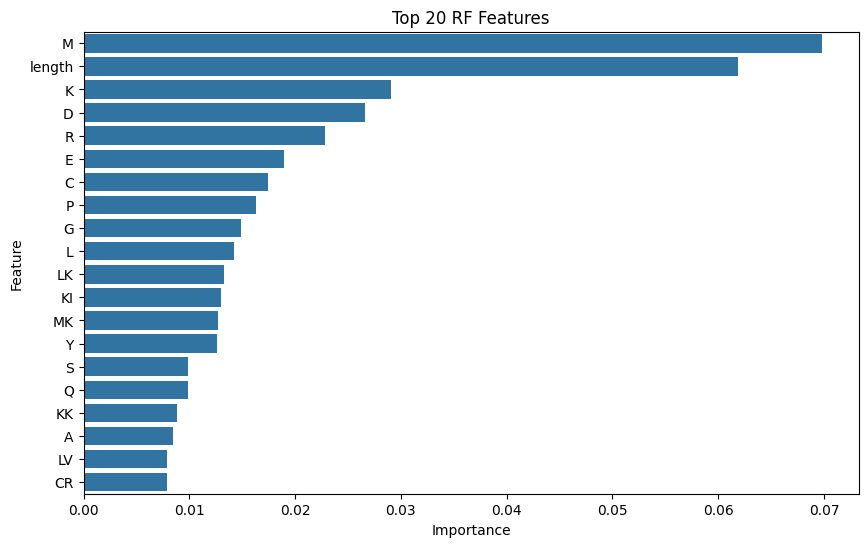

In [ ]:
top20 = feature_importance.head(20)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top20,
    x='Importance',
    y='Feature'
)

plt.title("Top 20 RF Features")
plt.show()

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    random_state = 42,
    eval_metric = 'logloss'
)
xgb.fit(x_train,y_train)
y_train_pred = xgb.predict(x_train)
y_test_pred = xgb.predict(x_test)
print('Accuracy of the training data : ',accuracy_score(y_train,y_train_pred))
print('Accuracy of the test data : ',accuracy_score(y_test,y_test_pred))
print('recall : ',recall_score(y_test,y_test_pred))
print('f1 score : ',f1_score(y_test,y_test_pred))
print('precision : ',precision_score(y_test,y_test_pred))
print(classification_report(y_test,y_test_pred))
cm = confusion_matrix(y_test,y_test_pred)
print('confusion matrix : \n',confusion_matrix(y_test,y_test_pred))

Accuracy of the training data :  1.0
Accuracy of the test data :  0.9140378548895899
recall :  0.8882575757575758
f1 score :  0.8958930276981852
precision :  0.9036608863198459
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       740
           1       0.90      0.89      0.90       528

    accuracy                           0.91      1268
   macro avg       0.91      0.91      0.91      1268
weighted avg       0.91      0.91      0.91      1268

confusion matrix : 
 [[690  50]
 [ 59 469]]


In [ ]:
top50_features = feature_importance.head(50)['Feature']

x_top50 = x_new[top50_features]

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_top50,y,random_state=42,test_size=0.2,stratify=y)

In [ ]:
rf_top50 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_top50.fit(x_train, y_train)
y_trian_pred = rf_top50.predict(x_train)
y_test_pred = rf_top50.predict(x_test)
print('Accuracy of trained data : ',accuracy_score(y_train,y_train_pred))
print('Accuracy of the test data : ',accuracy_score(y_test,y_test_pred))
print('precision : ',precision_score(y_test,y_test_pred))
print('Recall : ',recall_score(y_test,y_test_pred))
print('F1 score : ',f1_score(y_test,y_test_pred))
cm = confusion_matrix(y_test,y_test_pred)
print('confusion matrix : \n',confusion_matrix(y_test,y_test_pred))

Accuracy of trained data :  1.0
Accuracy of the test data :  0.9156151419558359
precision :  0.9103313840155945
Recall :  0.884469696969697
F1 score :  0.8972142170989433
confusion matrix : 
 [[694  46]
 [ 61 467]]


In [ ]:
# top25_features = feature_importance.head(25)['Feature']

# x_top25 = x_new[top25_features]

In [ ]:
# = train_test_split(x_top25,y,random_sfrom sklearn.model_selection import train_test_split
# x_train,x_test,y_train,y_test tate=42,test_size=0.2,stratify=y)

In [ ]:
# rf_dpc.fit(x_train, y_train)
# y_trian_pred = rf_dpc.predict(x_train)
# y_test_pred = rf_dpc.predict(x_test)
# print('Accuracy of trained data : ',accuracy_score(y_train,y_train_pred))
# print('Accuracy of the test data : ',accuracy_score(y_test,y_test_pred))
# print('precision : ',precision_score(y_test,y_test_pred))
# print('Recall : ',recall_score(y_test,y_test_pred))
# print('F1 score : ',f1_score(y_test,y_test_pred))
# cm = confusion_matrix(y_test,y_test_pred)
# print('confusion matrix : \n',confusion_matrix(y_test,y_test_pred))

No top 25 features model failed (crossed elbow) noticable fall in accuracy

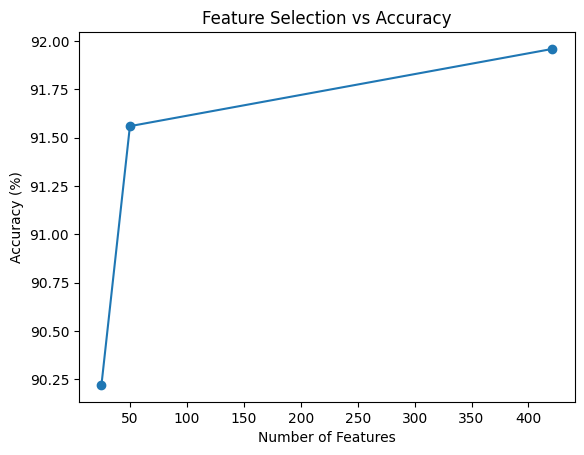

In [ ]:
features = [25,50,421]
accuracy = [90.22,91.56,91.96]

plt.plot(features, accuracy, marker='o')
plt.xlabel("Number of Features")
plt.ylabel("Accuracy (%)")
plt.title("Feature Selection vs Accuracy")
plt.show()

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(
    rf_top50
)

In [ ]:
x_sample = x_test.iloc[:100]
shap_values = explainer.shap_values(
    x_test
)

In [ ]:
shap_amp = shap_values[:, :, 1]

In [ ]:
shap_amp.shape

(1268, 50)

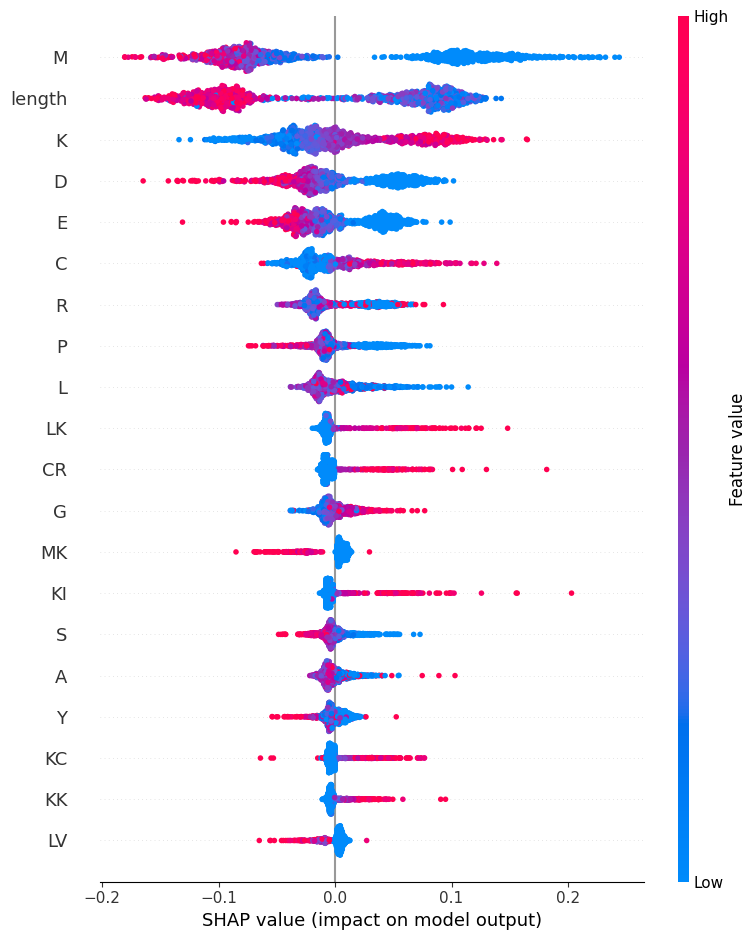

In [ ]:
shap.summary_plot(
    shap_amp,
    x_test,
    plot_type='dot'
)

In [ ]:
import numpy as np
import pandas as pd
shap_importance = pd.DataFrame({
    'Feature': x_test.columns,
    'Mean_SHAP': np.abs(shap_amp).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by='Mean_SHAP',
    ascending=False
)

print(shap_importance.head(20))

   Feature  Mean_SHAP
0        M   0.096427
1   length   0.088454
2        K   0.041843
3        D   0.035843
5        E   0.029861
6        C   0.024832
4        R   0.023178
7        P   0.017849
9        L   0.015725
10      LK   0.012639
19      CR   0.010979
8        G   0.010079
12      MK   0.009981
11      KI   0.009964
14       S   0.009154
17       A   0.008011
13       Y   0.007006
25      KC   0.006995
16      KK   0.006552
18      LV   0.006544


Explaining single peptide prediction

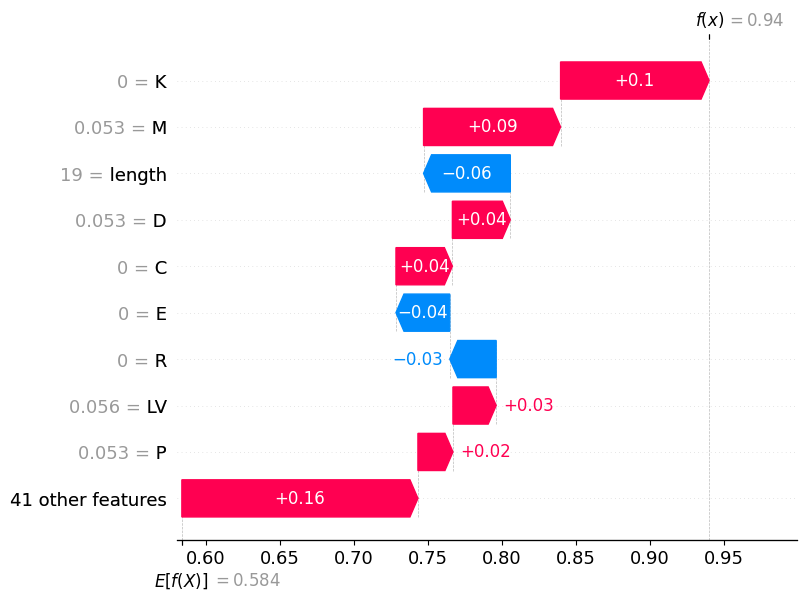

In [ ]:
sample = x_test.iloc[[0]]
shap_exp = explainer(sample)
shap.plots.waterfall(
    shap_exp[0,:,0]
)

In [ ]:
import pandas as pd
import numpy as np

def predict_amp(sequence):

    sequence = sequence.upper()

    # ---------- AAC ----------
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"

    aac_features = {}

    seq_len = len(sequence)

    for aa in amino_acids:
        aac_features[aa] = sequence.count(aa) / seq_len

    # ---------- DPC ----------
    dpc_features = {}

    dipeptides = [
        aa1 + aa2
        for aa1 in amino_acids
        for aa2 in amino_acids
    ]

    for dp in dipeptides:
        dpc_features[dp] = 0

    for i in range(len(sequence)-1):

        dp = sequence[i:i+2]

        if dp in dpc_features:
            dpc_features[dp] += 1

    total_dp = len(sequence)-1

    if total_dp > 0:
        for dp in dpc_features:
            dpc_features[dp] /= total_dp

    # ---------- Combine Features ----------
    features = {}

    features.update(aac_features)
    features.update(dpc_features)

    features["length"] = seq_len

    # ---------- DataFrame ----------
    x = pd.DataFrame([features])

    # ---------- Select Top50 ----------
    x = x[top50_features]

    # ---------- Prediction ----------
    pred = rf_top50.predict(x)[0]

    prob = rf_top50.predict_proba(x)[0][1]

    result = {
        "Prediction": "AMP" if pred == 1 else "non-AMP",
        "Probability": round(prob * 100, 2)
    }

    return result

In [ ]:
predict_amp("KKRLLKLLKKLL")

{'Prediction': 'AMP', 'Probability': np.float64(92.0)}

In [ ]:
predict_amp(
    "MDEQELDQLAEQKLAEELDKLQEE"
)

{'Prediction': 'non-AMP', 'Probability': np.float64(36.0)}

In [ ]:
import joblib

joblib.dump(
    rf_top50,
    "rf_top50.pkl"
)

['rf_top50.pkl']

In [ ]:
joblib.dump(
    list(top50_features),
    "top50_features.pkl"
)

['top50_features.pkl']